<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-1"><span class="toc-item-num">1&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#FashionMNIST" data-toc-modified-id="FashionMNIST-2"><span class="toc-item-num">2&nbsp;&nbsp;</span><b>FashionMNIST</b></a></span></li><li><span><a href="#Данные" data-toc-modified-id="Данные-3"><span class="toc-item-num">3&nbsp;&nbsp;</span><b>Данные</b></a></span></li><li><span><a href="#Задание" data-toc-modified-id="Задание-4"><span class="toc-item-num">4&nbsp;&nbsp;</span><b>Задание</b></a></span></li></ul></div>

---

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

---

В этом ноутбуке Вам предстоит самостоятельно попрактиковаться в написаноо нейросетей для распознавания датасета, похожего на MNIST, но более интересного -- чёрно-белых изображений одежды.

<h2 style="text-align: center;"><b>FashionMNIST</b></h2>

<img src="https://emiliendupont.github.io/imgs/mnist-chicken/mnist-and-fashion-examples.png">

<h2 style="text-align: center;"><b>Данные</b></h2>

Мы будем работать с картинками одежды (чёрно-белыми, то есть цветовых каналов не 3, а 1). По входной картинке нужно предсказать тип одежды.

In [1]:
# !pip install torchvision

import numpy as np
import matplotlib.pyplot as plt

import torch
import torchvision

In [2]:
trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                        download=True, transform=None)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=4,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                       download=True, transform=None)
testloader = torch.utils.data.DataLoader(testset, batch_size=4,
                                         shuffle=False, num_workers=2)

#classes = (<перечислите классы как строки>)

100.0%
100.0%
100.0%
100.0%


Каждая картинка имеет класс от 0 до 9, расшифровка меток класса:  

|class_id|class_name|
|----|----|
|0| T-shirt/top|
|1| Trouser|
|2| Pullover|
|3| Dress|
|4| Coat|
|5| Sandal|
|6| Shirt|
|7| Sneaker|
|8| Bag|
|9| Ankle boot| 

Посмотрите на датасет.
* Сколько в нём классов?
* Сколько картинок в train? В test?
* Выведите несколько картинок с помощью `pyplot`

Количество классов: 10
Количество картинок в train: 60000
Количество картинок в test:  10000


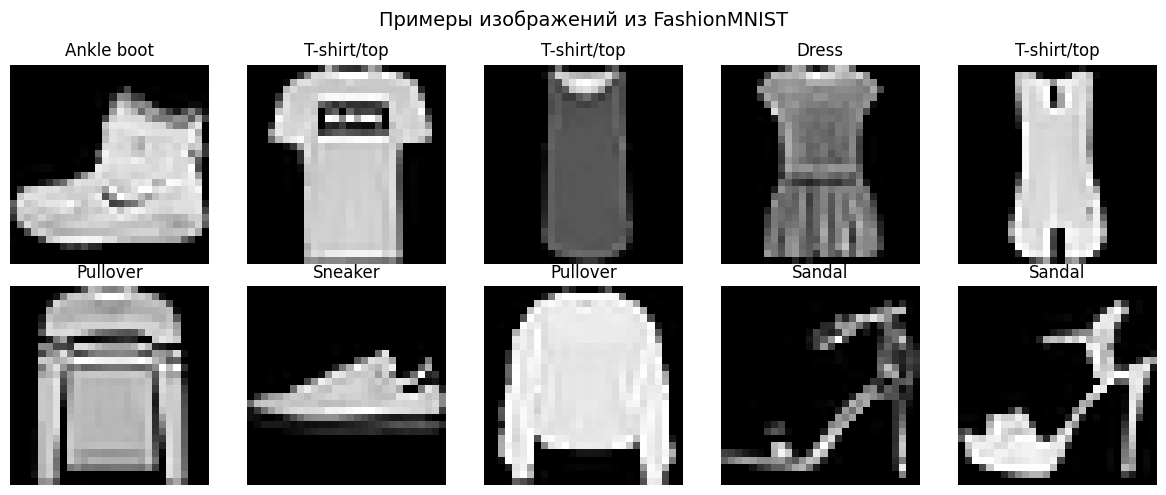

In [3]:
classes = (
    'T-shirt/top',  
    'Trouser',      
    'Pullover',     
    'Dress',        
    'Coat',         
    'Sandal',       
    'Shirt',        
    'Sneaker',      
    'Bag',          
    'Ankle boot'    
)

print(f"Количество классов: {len(classes)}")
print(f"Количество картинок в train: {len(trainset)}")
print(f"Количество картинок в test:  {len(testset)}")
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
axes = axes.flatten()
for i in range(10):
    image, label = trainset[i]
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(classes[label])
    axes[i].axis('off')
plt.suptitle('Примеры изображений из FashionMNIST', fontsize=14)
plt.tight_layout()
plt.show()

<h2 style="text-align: center;"><b>Задание</b></h2>

Используя материалы семинаров по многослойным  и свёрточным сетям, напишите Свёрточную сеть, классифицирующую этот датасет.
Если качество, которое получается у  нейросети, выше 95%, то Вы решили задачу с точностью, которую можно использовать в жизни.

Используем: cpu
FashionCNN(
  (block1): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Dropout2d(p=0.25, inplace=False)
  )
  (block2): Sequential(
    (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=

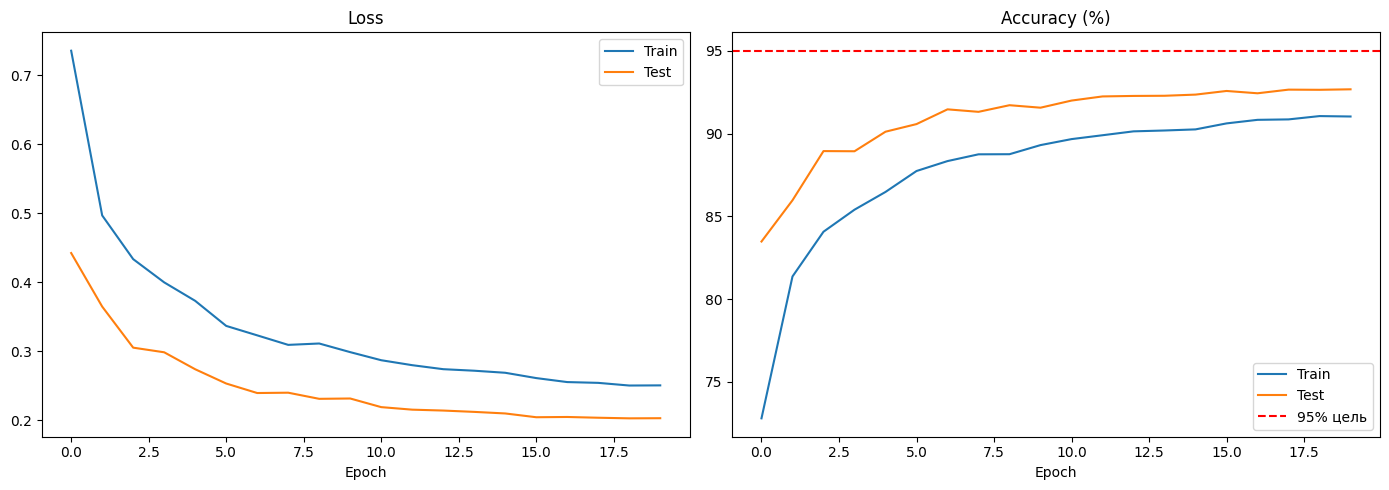


Итоговая точность на тесте: 92.67%


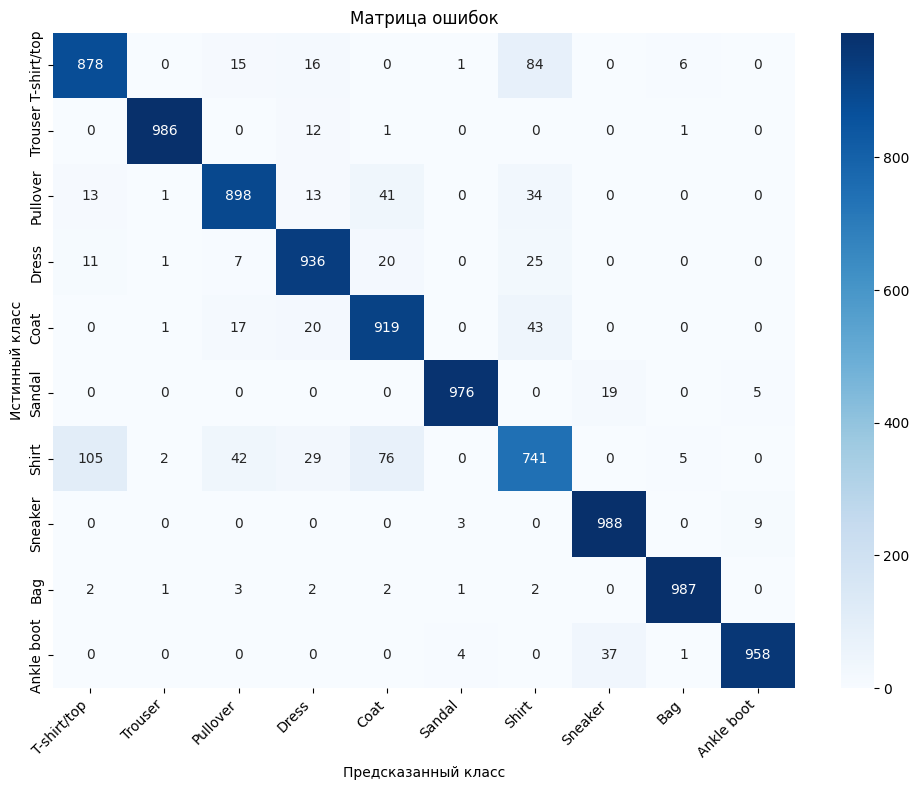


── Точность по классам ──────────────────────────────────────────────
[OK  ] [0] T-shirt/top  █████████████████░░░  87.80%
[OK  ] [1] Trouser      ███████████████████░  98.60%
[OK  ] [2] Pullover     █████████████████░░░  89.80%
[OK  ] [3] Dress        ██████████████████░░  93.60%
[OK  ] [4] Coat         ██████████████████░░  91.90%
[OK  ] [5] Sandal       ███████████████████░  97.60%
[OK  ] [6] Shirt        ██████████████░░░░░░  74.10%
[OK  ] [7] Sneaker      ███████████████████░  98.80%
[OK  ] [8] Bag          ███████████████████░  98.70%
[OK  ] [9] Ankle boot   ███████████████████░  95.80%

Средняя точность : 92.67%
Минимальная      : 74.10%  (Shirt)
Максимальная     : 98.80%  (Sneaker)


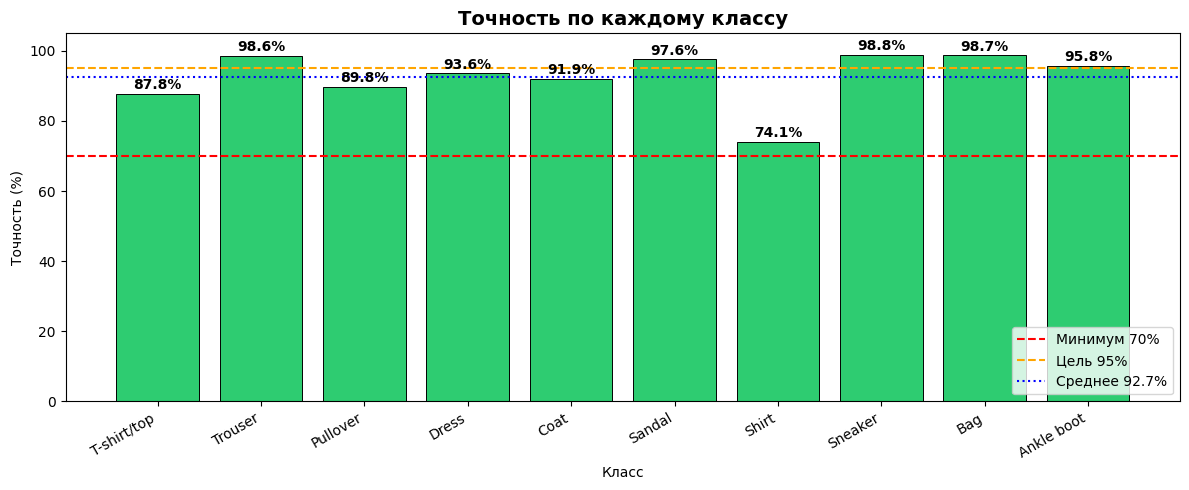


 Все классы выше порога 70%!


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используем: {device}")

transform_train = transforms.Compose([
    transforms.RandomHorizontalFlip(),          
    transforms.RandomCrop(28, padding=4),       
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))  
])

transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

trainset = torchvision.datasets.FashionMNIST(root='./data', train=True,
                                              download=True, transform=transform_train)
testset  = torchvision.datasets.FashionMNIST(root='./data', train=False,
                                              download=True, transform=transform_test)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True,  num_workers=2)
testloader  = DataLoader(testset,  batch_size=64, shuffle=False, num_workers=2)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
           'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot')

class FashionCNN(nn.Module):
    def __init__(self):
        super(FashionCNN, self).__init__()

        # Блок 1: 1 → 32 канала, карта 28×28 → 14×14
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),  # 28×28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # 28×28
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 14×14
            nn.Dropout2d(0.25)
        )

        # Блок 2: 32 → 64 канала, карта 14×14 → 7×7
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1), # 14×14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1), # 14×14
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                          # 7×7
            nn.Dropout2d(0.25)
        )

        # Блок 3: 64 → 128 каналов, карта 7×7 → 3×3
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1), # 7×7
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2),                           # 3×3
            nn.Dropout2d(0.25)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 3 * 3, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x

model = FashionCNN().to(device)
print(model)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"\nОбучаемых параметров: {total_params:,}")

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)

def train_epoch(model, loader, optimizer, criterion):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()
        total += labels.size(0)

    return running_loss / total, 100. * correct / total

def evaluate(model, loader, criterion):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()
            total += labels.size(0)

    return running_loss / total, 100. * correct / total

EPOCHS = 20
history = {'train_loss': [], 'train_acc': [], 'test_loss': [], 'test_acc': []}

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, trainloader, optimizer, criterion)
    test_loss,  test_acc  = evaluate(model, testloader, criterion)
    scheduler.step()

    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['test_loss'].append(test_loss)
    history['test_acc'].append(test_acc)

    print(f"Epoch [{epoch:2d}/{EPOCHS}] "
          f"Train loss: {train_loss:.4f}, acc: {train_acc:.2f}% | "
          f"Test  loss: {test_loss:.4f}, acc: {test_acc:.2f}%")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['test_loss'],  label='Test')
ax1.set_title('Loss'); ax1.set_xlabel('Epoch'); ax1.legend()

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['test_acc'],  label='Test')
ax2.axhline(95, color='red', linestyle='--', label='95% цель')
ax2.set_title('Accuracy (%)'); ax2.set_xlabel('Epoch'); ax2.legend()

plt.tight_layout()
plt.show()

print(f"\nИтоговая точность на тесте: {history['test_acc'][-1]:.2f}%")

from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images.to(device))
        _, predicted = outputs.max(1)
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.title('Матрица ошибок')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("\n── Точность по классам ──────────────────────────────────────────────")
class_correct = np.zeros(10)
class_total   = np.zeros(10)

for true, pred in zip(all_labels, all_preds):
    class_total[true] += 1
    if true == pred:
        class_correct[true] += 1

class_acc = 100. * class_correct / class_total

for i, (cls, acc) in enumerate(zip(classes, class_acc)):
    status = "OK  " if acc >= 70 else "FAIL"
    bar    = "█" * int(acc // 5) + "░" * (20 - int(acc // 5))
    print(f"[{status}] [{i}] {cls:<12} {bar} {acc:6.2f}%")
print(f"\nСредняя точность : {class_acc.mean():.2f}%")
print(f"Минимальная      : {class_acc.min():.2f}%  ({classes[class_acc.argmin()]})")
print(f"Максимальная     : {class_acc.max():.2f}%  ({classes[class_acc.argmax()]})")


colors = ['#2ecc71' if acc >= 70 else '#e74c3c' for acc in class_acc]

plt.figure(figsize=(12, 5))
bars = plt.bar(classes, class_acc, color=colors, edgecolor='black', linewidth=0.7)

for bar, acc in zip(bars, class_acc):
    plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
             f'{acc:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.axhline(70,  color='red',    linestyle='--', linewidth=1.5, label='Минимум 70%')
plt.axhline(95,  color='orange', linestyle='--', linewidth=1.5, label='Цель 95%')
plt.axhline(class_acc.mean(), color='blue', linestyle=':',
            linewidth=1.5, label=f'Среднее {class_acc.mean():.1f}%')

plt.ylim(0, 105)
plt.title('Точность по каждому классу', fontsize=14, fontweight='bold')
plt.xlabel('Класс')
plt.ylabel('Точность (%)')
plt.xticks(rotation=30, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

failed = [(classes[i], class_acc[i]) for i in range(10) if class_acc[i] < 70]
if failed:
    print("\n  Классы ниже порога 70%:")
    for cls, acc in failed:
        print(f"   • {cls}: {acc:.2f}%")
else:
    print("\n Все классы выше порога 70%!")

In [ ]:
...

In [ ]:
...